In [1]:

%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from tesa_m1 import ActiveSuspension


MOJE_S = 791

# Inicjalizacja modelu
model = ActiveSuspension(MOJE_S)


In [2]:
from IPython.display import display, Markdown

# Skrót do obiektu modelu
m = model 

# Sekcja 1: Parametry
# Używamy f-stringa (rf""), podwójne klamry {{ }} to LaTeX, pojedyncze { } to zmienne Python
parametry_html = rf"""
## 1. Indywidualizacja Parametrów Projektowych

Parametry modelu ćwiartkowego zostały wyznaczone na podstawie indywidualnego numeru $S$.
Dla przyjętego **$S = {m.S}$**, wartości wynoszą:

### A. Parametry Masowe
* Masa resorowana (nadwozie):
$$m_s = 280 + 0.4 S = 280 + 0.4({m.S}) = \mathbf{{{m.ms:.1f}}} \text{{ kg}}$$
* Masa nieresorowana (zespół koła):
$$m_u = 35 + 0.05 S = 35 + 0.05({m.S}) = \mathbf{{{m.mu:.2f}}} \text{{ kg}}$$

### B. Parametry Sprężyste
* Sztywność zawieszenia:
$$k_s = (18 + 0.02 S) \cdot 10^3 = \mathbf{{{m.ks:.0f}}} \text{{ N/m}}$$
* Sztywność opony:
$$k_t = (150 + 0.05 S) \cdot 10^3 = \mathbf{{{m.kt:.0f}}} \text{{ N/m}}$$

### C. Parametry Tłumiące
* Współczynnik tłumienia zawieszenia:
$$c_s = (1.4 + 0.002 S) \cdot 10^3 = \mathbf{{{m.cs:.0f}}} \text{{ Ns/m}}$$
* Współczynnik tłumienia opony:
$$c_t = (0.4 + 0.001 S) \cdot 10^3 = \mathbf{{{m.ct:.0f}}} \text{{ Ns/m}}$$

### D. Element Wykonawczy
* Ograniczenie siły sterującej:
$$|u| \le \mathbf{{{m.u_max:.0f}}} \text{{ N}}$$
"""

display(Markdown(parametry_html))


## 1. Indywidualizacja Parametrów Projektowych

Parametry modelu ćwiartkowego zostały wyznaczone na podstawie indywidualnego numeru $S$.
Dla przyjętego **$S = 791$**, wartości wynoszą:

### A. Parametry Masowe
* Masa resorowana (nadwozie):
$$m_s = 280 + 0.4 S = 280 + 0.4(791) = \mathbf{596.4} \text{ kg}$$
* Masa nieresorowana (zespół koła):
$$m_u = 35 + 0.05 S = 35 + 0.05(791) = \mathbf{74.55} \text{ kg}$$

### B. Parametry Sprężyste
* Sztywność zawieszenia:
$$k_s = (18 + 0.02 S) \cdot 10^3 = \mathbf{33820} \text{ N/m}$$
* Sztywność opony:
$$k_t = (150 + 0.05 S) \cdot 10^3 = \mathbf{189550} \text{ N/m}$$

### C. Parametry Tłumiące
* Współczynnik tłumienia zawieszenia:
$$c_s = (1.4 + 0.002 S) \cdot 10^3 = \mathbf{2982} \text{ Ns/m}$$
* Współczynnik tłumienia opony:
$$c_t = (0.4 + 0.001 S) \cdot 10^3 = \mathbf{1191} \text{ Ns/m}$$

### D. Element Wykonawczy
* Ograniczenie siły sterującej:
$$|u| \le \mathbf{3000} \text{ N}$$


In [3]:
from IPython.display import display, Markdown

# Alias dla wygody
m = model 

wyprowadzenie_full_symbolic = rf"""
## 2. Model Matematyczny w Przestrzeni Stanu

### Równania różniczkowe
Układ 2-DOF opisany jest bilansem sił:

1. **Masa resorowana ($m_s$):**
$$m_{{s}}\ddot{{z}}_{{s}} = -k_{{s}}(z_{{s}}-z_{{u}}) - c_{{s}}(\dot{{z}}_{{s}}-\dot{{z}}_{{u}}) + u$$

2. **Masa nieresorowana ($m_u$):**
$$m_{{u}}\ddot{{z}}_{{u}} = k_{{s}}(z_{{s}}-z_{{u}}) + c_{{s}}(\dot{{z}}_{{s}}-\dot{{z}}_{{u}}) - k_{{t}}(z_{{u}}-r) - c_{{t}}(\dot{{z}}_{{u}}-\dot{{r}}) - u$$

### Definicja zmiennych
Przyjęto wektor stanu $x$ (z prędkością względną $x_4$) oraz uproszczony wektor zakłóceń $w$:
$$
x = \begin{{bmatrix}} z_s - z_u \\ \dot{{z}}_s \\ z_u - r \\ \dot{{z}}_u - \dot{{r}} \end{{bmatrix}}, \quad
w = \begin{{bmatrix}} r \\ \dot{{r}} \end{{bmatrix}}
$$

### Równanie Stanu ($\dot{{x}} = Ax + Bu + Ew$)
Dla parametrów indywidualnych ($S={m.S}$), macierze przyjmują postać:

**Macierz Dynamiki A:**
$$
A = \begin{{bmatrix}}
0 & 1 & 0 & -1 \\
-\frac{{k_s}}{{m_s}} & -\frac{{c_s}}{{m_s}} & 0 & \frac{{c_s}}{{m_s}} \\
0 & 0 & 0 & 1 \\
\frac{{k_s}}{{m_u}} & \frac{{c_s}}{{m_u}} & -\frac{{k_t}}{{m_u}} & -\frac{{c_s+c_t}}{{m_u}}
\end{{bmatrix}}
= \begin{{bmatrix}}
{m.A[0,0]:.0f} & {m.A[0,1]:.0f} & {m.A[0,2]:.0f} & {m.A[0,3]:.0f} \\
{m.A[1,0]:.2f} & {m.A[1,1]:.2f} & {m.A[1,2]:.2f} & {m.A[1,3]:.2f} \\
{m.A[2,0]:.0f} & {m.A[2,1]:.0f} & {m.A[2,2]:.0f} & {m.A[2,3]:.0f} \\
{m.A[3,0]:.2f} & {m.A[3,1]:.2f} & {m.A[3,2]:.2f} & {m.A[3,3]:.2f}
\end{{bmatrix}}
$$

**Macierz Wejść Sterujących B:**
$$
B = \begin{{bmatrix}} 0 \\ \frac{{1}}{{m_s}} \\ 0 \\ -\frac{{1}}{{m_u}} \end{{bmatrix}}
= \begin{{bmatrix}} 0 \\ {m.B[1,0]:.5f} \\ 0 \\ {m.B[3,0]:.5f} \end{{bmatrix}}
$$

**Macierz Zakłóceń E:**
$$
E = \begin{{bmatrix}} 0 & -1 \\ 0 & \frac{{c_s}}{{m_s}} \\ 0 & 0 \\ 0 & -\frac{{c_s}}{{m_u}} \end{{bmatrix}}
= \begin{{bmatrix}} 0 & -1 \\ 0 & {m.E[1,1]:.2f} \\ 0 & 0 \\ 0 & {m.E[3,1]:.2f} \end{{bmatrix}}
$$

### Równanie Wyjścia ($y = Cx + Du$)
[cite_start]Zdefiniowano wektor wyjść pomiarowych i metryk jakości:
$$y = [\dot{{z}}_s, \quad z_u - r, \quad z_s - z_u]^T$$

**Macierz Wyjścia C:**
$$
C = \begin{{bmatrix}}
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
1 & 0 & 0 & 0 
\end{{bmatrix}}
$$

**Macierz Bezpośrednia D:**
$$
D = \begin{{bmatrix}} 0 \\ 0 \\ 0 \end{{bmatrix}}
$$
"""

display(Markdown(wyprowadzenie_full_symbolic))


## 2. Model Matematyczny w Przestrzeni Stanu

### Równania różniczkowe
Układ 2-DOF opisany jest bilansem sił:

1. **Masa resorowana ($m_s$):**
$$m_{s}\ddot{z}_{s} = -k_{s}(z_{s}-z_{u}) - c_{s}(\dot{z}_{s}-\dot{z}_{u}) + u$$

2. **Masa nieresorowana ($m_u$):**
$$m_{u}\ddot{z}_{u} = k_{s}(z_{s}-z_{u}) + c_{s}(\dot{z}_{s}-\dot{z}_{u}) - k_{t}(z_{u}-r) - c_{t}(\dot{z}_{u}-\dot{r}) - u$$

### Definicja zmiennych
Przyjęto wektor stanu $x$ (z prędkością względną $x_4$) oraz uproszczony wektor zakłóceń $w$:
$$
x = \begin{bmatrix} z_s - z_u \\ \dot{z}_s \\ z_u - r \\ \dot{z}_u - \dot{r} \end{bmatrix}, \quad
w = \begin{bmatrix} r \\ \dot{r} \end{bmatrix}
$$

### Równanie Stanu ($\dot{x} = Ax + Bu + Ew$)
Dla parametrów indywidualnych ($S=791$), macierze przyjmują postać:

**Macierz Dynamiki A:**
$$
A = \begin{bmatrix}
0 & 1 & 0 & -1 \\
-\frac{k_s}{m_s} & -\frac{c_s}{m_s} & 0 & \frac{c_s}{m_s} \\
0 & 0 & 0 & 1 \\
\frac{k_s}{m_u} & \frac{c_s}{m_u} & -\frac{k_t}{m_u} & -\frac{c_s+c_t}{m_u}
\end{bmatrix}
= \begin{bmatrix}
0 & 1 & 0 & -1 \\
-56.71 & -5.00 & 0.00 & 5.00 \\
0 & 0 & 0 & 1 \\
453.66 & 40.00 & -2542.59 & -55.98
\end{bmatrix}
$$

**Macierz Wejść Sterujących B:**
$$
B = \begin{bmatrix} 0 \\ \frac{1}{m_s} \\ 0 \\ -\frac{1}{m_u} \end{bmatrix}
= \begin{bmatrix} 0 \\ 0.00168 \\ 0 \\ -0.01341 \end{bmatrix}
$$

**Macierz Zakłóceń E:**
$$
E = \begin{bmatrix} 0 & -1 \\ 0 & \frac{c_s}{m_s} \\ 0 & 0 \\ 0 & -\frac{c_s}{m_u} \end{bmatrix}
= \begin{bmatrix} 0 & -1 \\ 0 & 5.00 \\ 0 & 0 \\ 0 & -40.00 \end{bmatrix}
$$

### Równanie Wyjścia ($y = Cx + Du$)
[cite_start]Zdefiniowano wektor wyjść pomiarowych i metryk jakości:
$$y = [\dot{z}_s, \quad z_u - r, \quad z_s - z_u]^T$$

**Macierz Wyjścia C:**
$$
C = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
1 & 0 & 0 & 0 
\end{bmatrix}
$$

**Macierz Bezpośrednia D:**
$$
D = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}
$$


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- M1b. Weryfikacja (S=791) ---
Status: PASSED


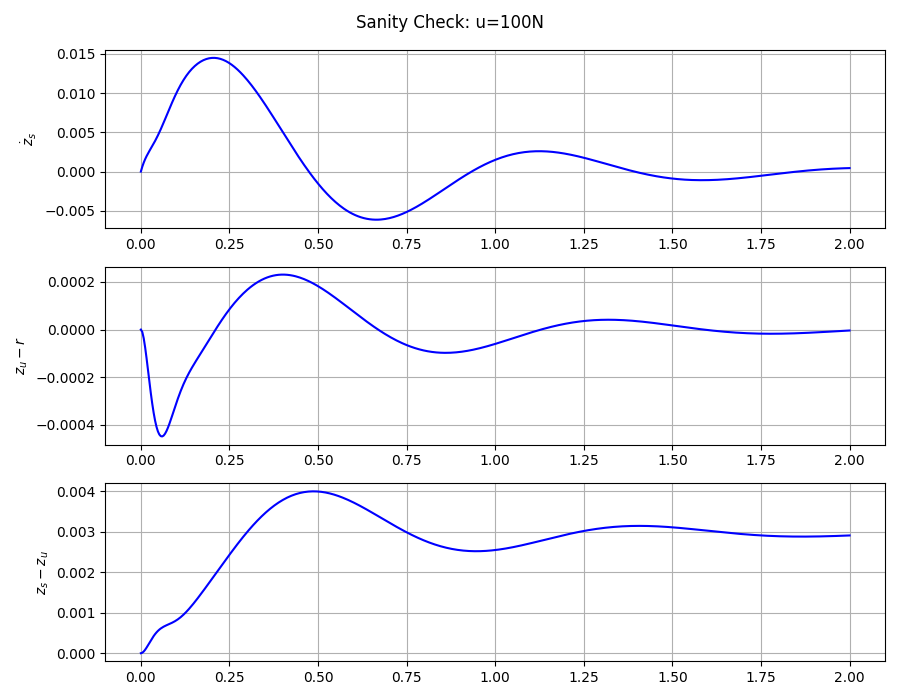

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from tesa_m1 import ActiveSuspension
#Uruchomienie weryfikacji (M1b)
t, y, status = model.run_sanity_check()

# Wyświetlenie wykresów
if status == "PASSED":
    model.plot_sanity_check(t, y)
else:
    print("Popraw błędy w modelu przed generowaniem wykresów!")

In [5]:
from IPython.display import display, Markdown

m = model 

raport_pomiary_simple = rf"""
## M2. Definicja Układu Pomiarowego

Przyjęto konfigurację czujników mierzącą bezpośrednio wybrane zmienne stanu:
1. **Prędkość pionowa nadwozia**: $y_{{pom,1}} = \dot{{z}}_s = x_2$
2. **Ugięcie zawieszenia**: $y_{{pom,2}} = z_s - z_u = x_1$

### Równanie wyjścia pomiarowego
Wektor pomiarowy $y_{{pom}} = C_{{pom}}x + D_{{pom}}u$ przyjmuje postać:

$$
y_{{pom}} = \begin{{bmatrix}} \dot{{z}}_s \\ z_s - z_u \end{{bmatrix}} = \begin{{bmatrix}} x_2 \\ x_1 \end{{bmatrix}}
$$

Dla tej konfiguracji macierze pomiarowe są stałe (niezależne od parametrów $S$) i bezinercyjne ($D_{{pom}}=0$):

$$
C_{{pom}} = \begin{{bmatrix}}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{{bmatrix}}, \quad
D_{{pom}} = \begin{{bmatrix}} 0 \\ 0 \end{{bmatrix}}
$$

### Analiza Obserwowalności (M2a)
Analiza rzędu macierzy Kalmana dla przyjętego zestawu czujników:
"""

display(Markdown(raport_pomiary_simple))


## M2. Definicja Układu Pomiarowego

Przyjęto konfigurację czujników mierzącą bezpośrednio wybrane zmienne stanu:
1. **Prędkość pionowa nadwozia**: $y_{pom,1} = \dot{z}_s = x_2$
2. **Ugięcie zawieszenia**: $y_{pom,2} = z_s - z_u = x_1$

### Równanie wyjścia pomiarowego
Wektor pomiarowy $y_{pom} = C_{pom}x + D_{pom}u$ przyjmuje postać:

$$
y_{pom} = \begin{bmatrix} \dot{z}_s \\ z_s - z_u \end{bmatrix} = \begin{bmatrix} x_2 \\ x_1 \end{bmatrix}
$$

Dla tej konfiguracji macierze pomiarowe są stałe (niezależne od parametrów $S$) i bezinercyjne ($D_{pom}=0$):

$$
C_{pom} = \begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 0 & 0
\end{bmatrix}, \quad
D_{pom} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}
$$

### Analiza Obserwowalności (M2a)
Analiza rzędu macierzy Kalmana dla przyjętego zestawu czujników:


In [6]:
import numpy as np
import control as ct

# Obliczenie macierzy obserwowalności
O_meas = ct.obsv(m.A, m.C_meas)
rank_O = np.linalg.matrix_rank(O_meas)
n_states = m.A.shape[0]

print(f"Wymiar stanu n: {n_states}")
print(f"Rząd macierzy obserwowalności rank(O): {rank_O}")

if rank_O == n_states:
    print("-> UKŁAD JEST OBSERWOWALNY. Można zaprojektować obserwator stanu.")
else:
    print("-> UWAGA: Układ nie jest obserwowalny.")

Wymiar stanu n: 4
Rząd macierzy obserwowalności rank(O): 4
-> UKŁAD JEST OBSERWOWALNY. Można zaprojektować obserwator stanu.


In [7]:
import numpy as np
import control as ct
from IPython.display import display, Markdown

# Alias
m = model

# 1. Obliczenia numeryczne
# Macierz obserwowalności Kalmana: O = [C; CA; CA^2; CA^3]
O_matrix = ct.obsv(m.A, m.C_meas)
rank_O = np.linalg.matrix_rank(O_matrix)
n_states = m.A.shape[0]

# Sprawdzenie warunku
is_observable = (rank_O == n_states)
status_color = "green" if is_observable else "red"
status_text = "UKŁAD JEST W PEŁNI OBSERWOWALNY" if is_observable else "UKŁAD NIE JEST OBSERWOWALNY"

# 2. Generowanie raportu
analiza_obserwowalnosci = rf"""
### 3. Analiza Obserwowalności (M2)

Aby zweryfikować możliwość odtworzenia pełnego wektora stanu na podstawie dostępnych pomiarów ($y_{{pom}}$), wyznaczono macierz obserwowalności Kalmana:
$$
\mathcal{{O}} = \begin{{bmatrix}} C_{{pom}} \\ C_{{pom}}A \\ C_{{pom}}A^2 \\ C_{{pom}}A^3 \end{{bmatrix}}
$$

Dla modelu o wymiarze stanu $n={n_states}$ oraz przyjętej macierzy pomiarowej $C_{{pom}}$ (prędkość nadwozia + ugięcie), wyniki analizy numerycznej są następujące:

* **Wymiar macierzy stanu:** $n = {n_states}$
* **Rząd macierzy obserwowalności:** $\text{{rank}}(\mathcal{{O}}) = \mathbf{{{rank_O}}}$

#### Wniosek
<span style="color:{status_color}; font-weight:bold">{status_text}</span>. 
Oznacza to, że para $(A, C_{{pom}})$ spełnia warunek Kalmana. Możliwe jest zaprojektowanie obserwatora stanu (np. Luenbergera), który estymuje wszystkie zmienne stanu (w tym niewierzoną prędkość koła i ugięcie opony) z dowolną dynamiką błędu.

#### Komentarz do doboru czujników
Wybrany zestaw czujników (akcelerometr całkujący/prędkościomierz oraz czujnik ugięcia) zapewnia obserwowalność, ponieważ:
1.  Pomiar $x_1$ (ugięcie) pozwala obserwować wzajemne przemieszczenie mas.
2.  Pomiar $x_2$ (prędkość) wnosi informację o energii kinetycznej masy resorowanej.
3.  Dynamika sprzężeń w macierzy $A$ (człony sprężyste i tłumiące) pozwala na tej podstawie wnioskować o zachowaniu masy nieresorowanej ($x_3, x_4$).

*Alternatywa minimalna:* Teoretycznie układ byłby obserwowalny nawet przy pomiarze wyłącznie ugięcia zawieszenia ($z_s-z_u$) lub wyłącznie prędkości nadwozia.
"""

display(Markdown(analiza_obserwowalnosci))


### 3. Analiza Obserwowalności (M2)

Aby zweryfikować możliwość odtworzenia pełnego wektora stanu na podstawie dostępnych pomiarów ($y_{pom}$), wyznaczono macierz obserwowalności Kalmana:
$$
\mathcal{O} = \begin{bmatrix} C_{pom} \\ C_{pom}A \\ C_{pom}A^2 \\ C_{pom}A^3 \end{bmatrix}
$$

Dla modelu o wymiarze stanu $n=4$ oraz przyjętej macierzy pomiarowej $C_{pom}$ (prędkość nadwozia + ugięcie), wyniki analizy numerycznej są następujące:

* **Wymiar macierzy stanu:** $n = 4$
* **Rząd macierzy obserwowalności:** $\text{rank}(\mathcal{O}) = \mathbf{4}$

#### Wniosek
<span style="color:green; font-weight:bold">UKŁAD JEST W PEŁNI OBSERWOWALNY</span>. 
Oznacza to, że para $(A, C_{pom})$ spełnia warunek Kalmana. Możliwe jest zaprojektowanie obserwatora stanu (np. Luenbergera), który estymuje wszystkie zmienne stanu (w tym niewierzoną prędkość koła i ugięcie opony) z dowolną dynamiką błędu.

#### Komentarz do doboru czujników
Wybrany zestaw czujników (akcelerometr całkujący/prędkościomierz oraz czujnik ugięcia) zapewnia obserwowalność, ponieważ:
1.  Pomiar $x_1$ (ugięcie) pozwala obserwować wzajemne przemieszczenie mas.
2.  Pomiar $x_2$ (prędkość) wnosi informację o energii kinetycznej masy resorowanej.
3.  Dynamika sprzężeń w macierzy $A$ (człony sprężyste i tłumiące) pozwala na tej podstawie wnioskować o zachowaniu masy nieresorowanej ($x_3, x_4$).

*Alternatywa minimalna:* Teoretycznie układ byłby obserwowalny nawet przy pomiarze wyłącznie ugięcia zawieszenia ($z_s-z_u$) lub wyłącznie prędkości nadwozia.


In [8]:
import numpy as np
import control as ct
from IPython.display import display, Markdown

m = model

# Macierz sterowalności Kalmana: R = [B, AB, A^2B, A^3B]
# W bibliotece python-control funkcja nazywa się ctrb()
R_matrix = ct.ctrb(m.A, m.B)
rank_R = np.linalg.matrix_rank(R_matrix)
n_states = m.A.shape[0]

# Logika wnioskowania
is_controllable = (rank_R == n_states)
status_color_ctrl = "green" if is_controllable else "red"
status_text_ctrl = "UKŁAD JEST STEROWALNY" if is_controllable else "UKŁAD NIE JEST STEROWALNY"

# 2. Generowanie raportu
analiza_sterowalnosci = rf"""
## Analiza Sterowalności

Analiza ma na celu sprawdzenie, czy za pomocą sterowania $u(t)$ (siły generowanej przez element aktywny) możliwe jest przeprowadzenie układu z dowolnego stanu początkowego do dowolnego stanu końcowego w skończonym czasie.

### Macierz Kalmana
Wyznaczono macierz sterowalności dla pary $(A, B)$:
$$
\mathcal{{C}} = \begin{{bmatrix}} B & AB & A^2B & A^3B \end{{bmatrix}}
$$

### Wyniki analizy
Dla badanego modelu ($S={m.S}$):
* **Wymiar macierzy stanu:** $n = {n_states}$
* **Rząd macierzy sterowalności:** $\text{{rank}}(\mathcal{{R}}) = \mathbf{{{rank_R}}}$

### Wniosek
<span style="color:{status_color_ctrl}; font-weight:bold">{status_text_ctrl}</span>.
Warunek Kalmana jest spełniony. Oznacza to, że teoretycznie możliwe jest zaprojektowanie regulatora (np. LQR lub placement biegunów), który ustabilizuje układ i zapewni dowolną dynamikę zamkniętej pętli.

### Komentarz praktyczny (Ograniczenia)
Mimo że układ jest *matematycznie* sterowalny w pełnym zakresie przestrzeni stanu, w rzeczywistości fizycznej sterowanie jest ograniczone parametrem:
$$|u| \le {m.u_max:.0f} \text{{ N}}$$
Oznacza to, że układ jest sterowalny tylko w obszarze stanów, dla których wymagana siła nie przekracza nasycenia elementu wykonawczego. Dla bardzo dużych wymuszeń (np. szybki wjazd na wysoki krawężnik) sterowalność może zostać chwilowo utracona z powodu nasycenia.
"""

display(Markdown(analiza_sterowalnosci))


## Analiza Sterowalności

Analiza ma na celu sprawdzenie, czy za pomocą sterowania $u(t)$ (siły generowanej przez element aktywny) możliwe jest przeprowadzenie układu z dowolnego stanu początkowego do dowolnego stanu końcowego w skończonym czasie.

### Macierz Kalmana
Wyznaczono macierz sterowalności dla pary $(A, B)$:
$$
\mathcal{C} = \begin{bmatrix} B & AB & A^2B & A^3B \end{bmatrix}
$$

### Wyniki analizy
Dla badanego modelu ($S=791$):
* **Wymiar macierzy stanu:** $n = 4$
* **Rząd macierzy sterowalności:** $\text{rank}(\mathcal{R}) = \mathbf{4}$

### Wniosek
<span style="color:green; font-weight:bold">UKŁAD JEST STEROWALNY</span>.
Warunek Kalmana jest spełniony. Oznacza to, że teoretycznie możliwe jest zaprojektowanie regulatora (np. LQR lub placement biegunów), który ustabilizuje układ i zapewni dowolną dynamikę zamkniętej pętli.

### Komentarz praktyczny (Ograniczenia)
Mimo że układ jest *matematycznie* sterowalny w pełnym zakresie przestrzeni stanu, w rzeczywistości fizycznej sterowanie jest ograniczone parametrem:
$$|u| \le 3000 \text{ N}$$
Oznacza to, że układ jest sterowalny tylko w obszarze stanów, dla których wymagana siła nie przekracza nasycenia elementu wykonawczego. Dla bardzo dużych wymuszeń (np. szybki wjazd na wysoki krawężnik) sterowalność może zostać chwilowo utracona z powodu nasycenia.


--- WYNIKI DLA UKŁADU BIERNEGO (BASELINE) ---

GARB (h=4cm): RMS Komfort = 0.0181, Max Skok = 28.8 mm


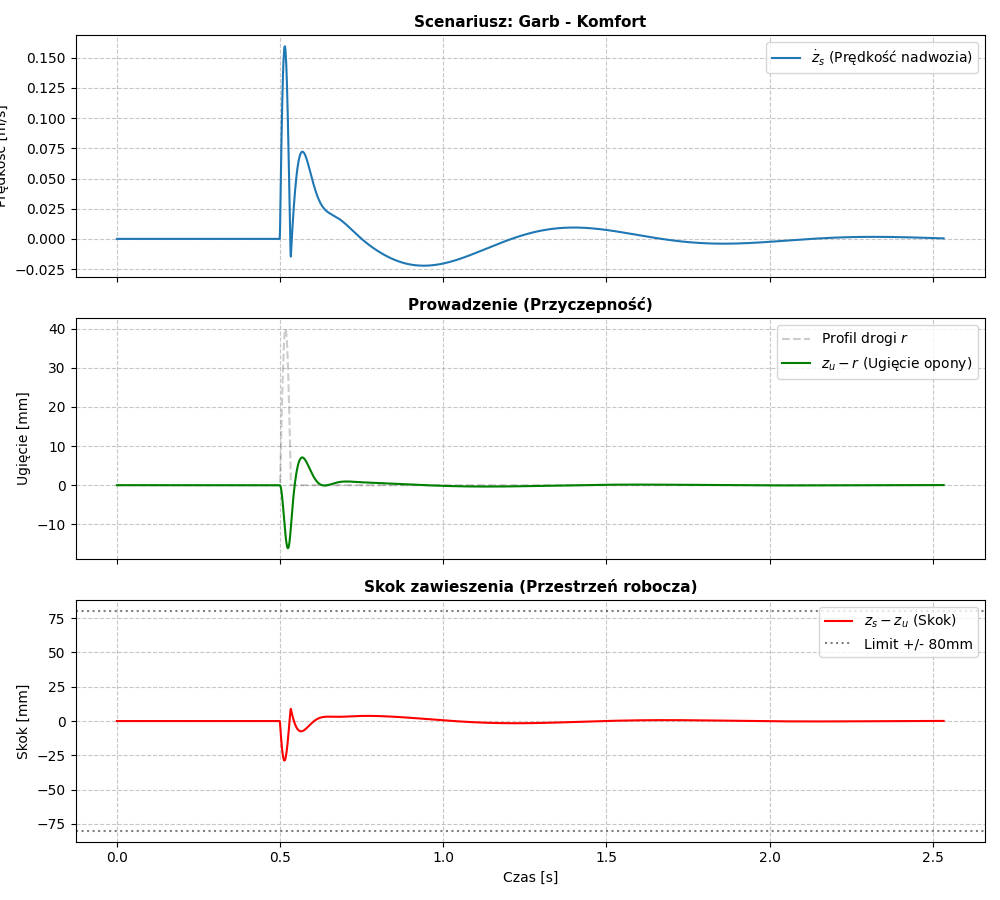


KRAWĘŻNIK (h=2cm): RMS Komfort = 0.0346, Max Skok = 19.1 mm


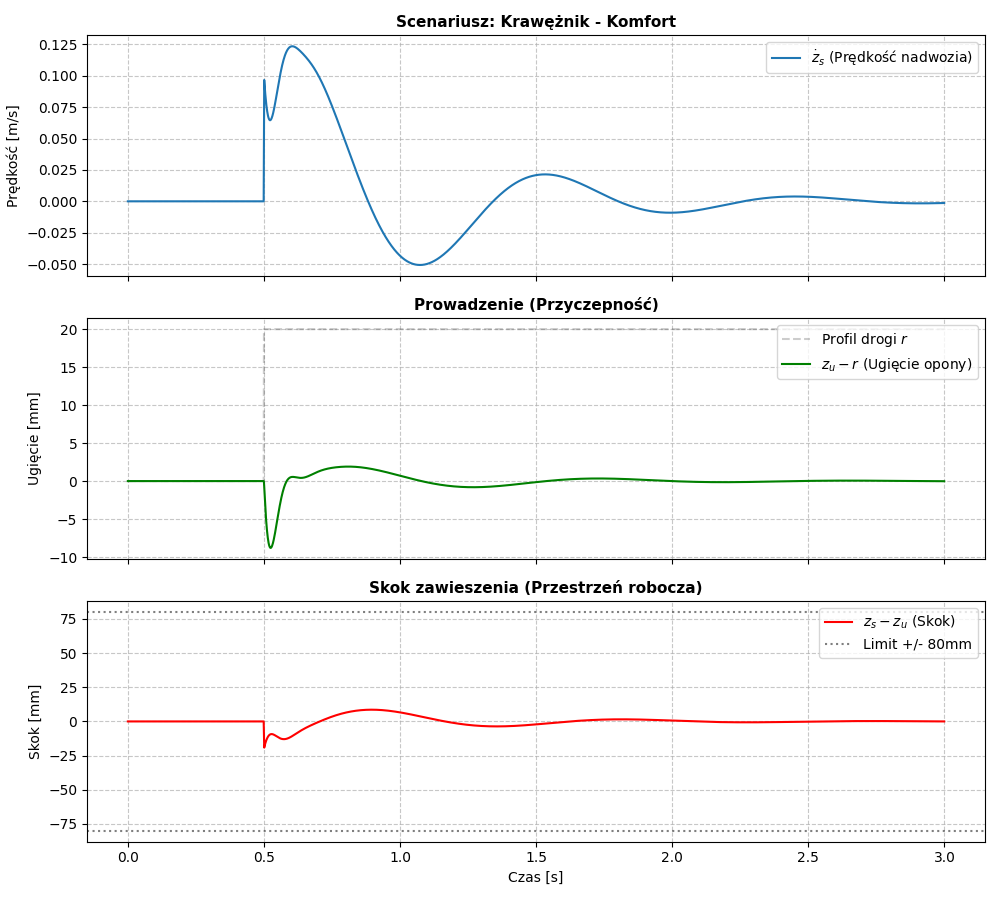

In [9]:
from tesa_validation import ValidationRunner
# Upewnij się, że obiekt 'model' z tesa_m1 jest załadowany
if 'model' in globals():
    validator = ValidationRunner(model)
    print("--- WYNIKI DLA UKŁADU BIERNEGO (BASELINE) ---")

    # 1. Garb
    t_b, y_b, r_b, m_b = validator.run_passive('bump', height=0.04, speed=15.0)
    print(f"\nGARB (h=4cm): RMS Komfort = {m_b['RMS_Comfort (zs_dot)']:.4f}, Max Skok = {m_b['Max_Suspension_Deflection']*1000:.1f} mm")
    validator.plot_results(t_b, y_b, r_b, "Scenariusz: Garb")

    # 2. Krawężnik (Impuls r_dot)
    t_c, y_c, r_c, m_c = validator.run_passive('curb', height=0.02)
    print(f"\nKRAWĘŻNIK (h=2cm): RMS Komfort = {m_c['RMS_Comfort (zs_dot)']:.4f}, Max Skok = {m_c['Max_Suspension_Deflection']*1000:.1f} mm")
    validator.plot_results(t_c, y_c, r_c, "Scenariusz: Krawężnik")
    
    # 3. Szum (opcjonalnie)
    # t_n, y_n, r_n, m_n = validator.run_passive('noise')
    # print(f"\nSZUM: RMS Komfort = {m_n['RMS_Comfort (zs_dot)']:.4f}")
else:
    print("BŁĄD: Obiekt 'model' nie został znaleziony. Uruchom najpierw komórki z definicją modelu.")

In [24]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, VBox, HBox, HTML, Layout

def interactive_pole_placement_m3(model):
    # Wyłączenie trybu interaktywnego na czas konfiguracji
    plt.ioff()
    
    # 1. Konfiguracja wykresu (Create Once)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.canvas.header_visible = False
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Linie danych (puste na start)
    line_zs_dot, = axes[0,0].plot([], [], 'b', lw=1.5)
    axes[0,0].set_title(r'Komfort: Prędkość $\dot{z}_s$ [m/s]')
    axes[0,0].grid(True)
    axes[0,0].axhline(0, color='k', lw=0.5)
    # Obszar tolerancji dla czasu regulacji (np. +/- 0.01 m/s)
    axes[0,0].axhline(0.01, color='g', linestyle=':', alpha=0.5)
    axes[0,0].axhline(-0.01, color='g', linestyle=':', alpha=0.5)
    
    line_zs_zu, = axes[0,1].plot([], [], 'g', lw=1.5)
    axes[0,1].set_title(r'Bezpieczeństwo: Ugięcie $z_s - z_u$ [mm]')
    axes[0,1].set_ylabel('mm')
    axes[0,1].grid(True)
    
    line_u, = axes[1,0].plot([], [], 'r', lw=1.5)
    axes[1,0].set_title(f'Sterowanie $u$ [N]')
    axes[1,0].grid(True)
    axes[1,0].axhline(model.u_max, color='k', linestyle='--', lw=1, label='Limit')
    axes[1,0].axhline(-model.u_max, color='k', linestyle='--', lw=1)
    
    # Tekst ostrzegawczy o nasyceniu
    text_sat = axes[1,0].text(0.5, 0.9, "NASYCENIE!", color='red', fontweight='bold', 
                              transform=axes[1,0].transAxes, ha='center', visible=False)
    
    # Mapa biegunów
    line_poles_dom, = axes[1,1].plot([], [], 'rx', ms=10, mew=2, label='Dominujące (Nadwozie)')
    line_poles_fast, = axes[1,1].plot([], [], 'bx', ms=8, mew=1.5, label='Szybkie (Koło)')
    axes[1,1].set_title('Rozkład biegunów (Root Locus)')
    axes[1,1].set_xlabel('Real')
    axes[1,1].set_ylabel('Imag')
    axes[1,1].grid(True)
    axes[1,1].legend(loc='lower left', fontsize='small')
    
    output_text = HTML(value="Inicjalizacja...")

    # 2. Funkcja obliczeniowa
    def update(change=None):
        zeta = w_zeta.value
        omega_n = w_omega.value
        pole_factor = w_factor.value
        
        # A. Wyznaczenie biegunów
        # Para dominująca (wolniejsza) - decyduje o komforcie
        p_dom_real = -zeta * omega_n
        p_dom_imag = omega_n * np.sqrt(1 - zeta**2 + 0j)
        p1 = complex(p_dom_real, np.real(p_dom_imag))
        p2 = complex(p_dom_real, -np.real(p_dom_imag))
        
        # Para szybka (szybsza) - decyduje o kole
        omega_fast = omega_n * pole_factor
        p_fast_real = -0.7 * omega_fast # Dajemy tłumienie 0.7 dla pary szybkiej
        p_fast_imag = omega_fast * np.sqrt(1 - 0.7**2)
        p3 = complex(p_fast_real, p_fast_imag)
        p4 = complex(p_fast_real, -p_fast_imag)
        
        desired_poles = [p1, p2, p3, p4]
        
        # B. Obliczenie K (Ackermann/Place)
        try:
            K = ct.place(model.A, model.B, desired_poles)
            K_str = np.array2string(K, precision=1)
        except Exception as e:
            output_text.value = f"<b style='color:red'>Błąd: {e}</b>"
            return

        # C. Symulacja scenariusza: Krawężnik (Curb)
        # Metoda sygnałowa: Skok r = Impuls r_dot
        dt = 0.001
        T_sim = np.arange(0, 1.5, dt) # 1.5s symulacji
        h_curb = 0.05 # 5 cm
        
        # Wymuszenie r_dot (impuls)
        r_dot_signal = np.zeros_like(T_sim)
        r_dot_signal[0] = h_curb / dt # Aproksymacja Diraca
        
        # Układ zamknięty
        A_cl = model.A - model.B @ K
        E_eff = model.E[:, [1]] # Wejście r_dot
        
        # Wyjścia: [zs_dot, zu-r, zs-zu, u]
        C_sim = np.vstack([
            [0, 1, 0, 0], # y1: zs_dot
            [0, 0, 1, 0], # y2: zu-r
            [1, 0, 0, 0], # y3: zs-zu
            -K            # y4: u
        ])
        D_sim = np.zeros((4, 1))
        
        sys_cl = ct.ss(A_cl, E_eff, C_sim, D_sim)
        
        # Obliczenie odpowiedzi
        _, y = ct.forced_response(sys_cl, T=T_sim, U=r_dot_signal)
        
        # Obsługa wymiarów (squeeze)
        if y.ndim == 1: y = y.reshape(4, -1) # Zabezpieczenie
        
        zs_dot = y[0]
        zs_zu = y[2]
        u_val = y[3]
        
        # D. Obliczenie metryk jakości (M3)
        max_u = np.max(np.abs(u_val))
        
        # Czas regulacji ts (dla zs_dot, kryterium 5% wartości szczytowej lub stała wartość np. 0.01)
        # Tutaj: czas po którym sygnał trwale wchodzi w pasmo +/- 0.02 m/s
        threshold = 0.02
        # Szukamy ostatniego momentu, gdzie |signal| > threshold
        out_of_bound_indices = np.where(np.abs(zs_dot) > threshold)[0]
        if len(out_of_bound_indices) > 0:
            ts_idx = out_of_bound_indices[-1]
            ts_val = T_sim[ts_idx]
        else:
            ts_val = 0.0
            
        ts_teoria = 4 / (zeta * omega_n) # Aproksymacja dla układu 2. rzędu
        
        # E. Aktualizacja wykresów
        line_zs_dot.set_data(T_sim, zs_dot)
        line_zs_zu.set_data(T_sim, zs_zu * 1000) # mm
        line_u.set_data(T_sim, u_val)
        
        line_poles_dom.set_data([p1.real, p2.real], [p1.imag, p2.imag])
        line_poles_fast.set_data([p3.real, p4.real], [p3.imag, p4.imag])
        
        # Skalowanie
        for ax in axes.flat:
            ax.relim()
            ax.autoscale_view()
        axes[1,1].set_xlim([-60, 2])
        axes[1,1].set_ylim([-60, 60])
        
        # Wskaźnik nasycenia
        if max_u > model.u_max:
            text_sat.set_visible(True)
            line_u.set_color('red')
        else:
            text_sat.set_visible(False)
            line_u.set_color('green')
            
        fig.canvas.draw_idle()
        
        # F. Raport tekstowy
        c_ts = "green" if ts_val < 0.4 else "red"
        c_u = "green" if max_u <= model.u_max else "red"
        
        status_html = f"""
        <div style="border: 1px solid #ccc; padding: 10px; background-color: #f8f9fa;">
            <h4>Wyniki strojenia (Krawężnik 5cm)</h4>
            <b>Regulator K:</b> {K_str}<br>
            <hr>
            <table style="width:100%">
                <tr>
                    <td><b>Metryka</b></td>
                    <td><b>Wartość</b></td>
                    <td><b>Wymaganie</b></td>
                    <td><b>Status</b></td>
                </tr>
                <tr>
                    <td>Czas regulacji $t_s$ (symulacja)</td>
                    <td>{ts_val:.3f} s</td>
                    <td>< 0.4 s</td>
                    <td style="color:{c_ts}"><b>{("OK" if ts_val < 0.4 else "ZA DŁUGO")}</b></td>
                </tr>
                <tr>
                    <td>Czas regulacji (teoria 2. rzędu)</td>
                    <td>{ts_teoria:.3f} s</td>
                    <td>-</td>
                    <td>-</td>
                </tr>
                <tr>
                    <td>Max siła sterująca $u_{{max}}$</td>
                    <td>{max_u:.0f} N</td>
                    <td>< 3000 N</td>
                    <td style="color:{c_u}"><b>{("OK" if max_u <= model.u_max else "NASYCENIE")}</b></td>
                </tr>
            </table>
        </div>
        """
        output_text.value = status_html

    # 3. Definicja suwaków
    style = {'description_width': 'initial'}
    layout = Layout(width='95%')
    
    # Zakresy zgodne z projektem
    w_zeta = FloatSlider(min=0.1, max=1.2, step=0.05, value=0.7, description='Zeta (0.6-0.9)', style=style, layout=layout)
    w_omega = FloatSlider(min=1.0, max=40.0, step=1.0, value=10.0, description='Omega_n (Szybkość)', style=style, layout=layout)
    w_factor = FloatSlider(min=1.0, max=10.0, step=0.5, value=4.0, description='Factor (Koło/Nadwozie)', style=style, layout=layout)

    w_zeta.observe(update, names='value')
    w_omega.observe(update, names='value')
    w_factor.observe(update, names='value')
    
    update() # Start
    
    plt.ion()
    ui = VBox([
        HBox([w_zeta, w_omega]),
        w_factor,
        output_text,
        fig.canvas
    ])
    display(ui)

# Uruchomienie narzędzia
interactive_pole_placement_m3(model)

In [31]:
from matplotlib.gridspec import GridSpec
from ipywidgets import FloatSlider, VBox, HBox, HTML, Layout
from tesa_validation import RoadProfileGenerator
# Zmienne globalne
K_pp = None
K_lqr = None

def setup_plots_common(model, title_suffix=""):
    fig = plt.figure(figsize=(10, 11))
    fig.canvas.header_visible = False
    gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1.2])
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    ax_comf = fig.add_subplot(gs[0, 0])
    ax_hand = fig.add_subplot(gs[0, 1])
    ax_susp = fig.add_subplot(gs[1, 0])
    ax_ctrl = fig.add_subplot(gs[1, 1])
    ax_pole = fig.add_subplot(gs[2, :])
    
    # Linie
    l_comf, = ax_comf.plot([], [], 'b', lw=1.5)
    ax_comf.set_title(r'Komfort: $\dot{z}_s$ [m/s]')
    ax_comf.grid(True, alpha=0.5)
    
    l_hand, = ax_hand.plot([], [], 'purple', lw=1.5)
    ax_hand.set_title(r'Prowadzenie: $z_u - r$ [mm]')
    ax_hand.set_ylabel('mm')
    ax_hand.grid(True, alpha=0.5)
    
    l_susp, = ax_susp.plot([], [], 'g', lw=1.5)
    ax_susp.set_title(r'Skok: $z_s - z_u$ [mm]')
    ax_susp.set_ylabel('mm')
    ax_susp.grid(True, alpha=0.5)
    ax_susp.axhline(80, color='r', linestyle='--', label='Limit 80')
    ax_susp.axhline(-80, color='r', linestyle='--')
    ax_susp.axhline(5, color='orange', linestyle=':', lw=2, label='Limit 10% (5mm)')
    ax_susp.legend(loc='lower right', fontsize='x-small')
    
    l_ctrl, = ax_ctrl.plot([], [], 'r', lw=1.5)
    ax_ctrl.set_title(f'Sterowanie $u$ [N]')
    ax_ctrl.grid(True, alpha=0.5)
    ax_ctrl.axhline(model.u_max, color='k', linestyle='--', label='Limit')
    ax_ctrl.axhline(-model.u_max, color='k', linestyle='--')
    txt_sat = ax_ctrl.text(0.5, 0.9, "NASYCENIE!", color='red', fontweight='bold', 
                           transform=ax_ctrl.transAxes, ha='center', visible=False)
    
    l_dom, = ax_pole.plot([], [], 'rx', ms=10, mew=2, label='Dominujące')
    l_fast, = ax_pole.plot([], [], 'bx', ms=8, mew=1.5, label='Szybkie')
    ax_pole.set_title(f'Mapa biegunów {title_suffix}')
    ax_pole.grid(True, alpha=0.5)
    ax_pole.legend(loc='lower left', fontsize='small')
    
    return fig, [ax_comf, ax_hand, ax_susp, ax_ctrl, ax_pole], [l_comf, l_hand, l_susp, l_ctrl, l_dom, l_fast], txt_sat

def run_simulation_with_generator(model, K):
    """
    Wspólna funkcja symulacyjna używająca RoadProfileGenerator.
    """
    # 1. Generacja wymuszenia (Krawężnik 5cm)
    gen = RoadProfileGenerator(dt=0.001)
    # start_time=0.1 żeby zobaczyć stan przed uderzeniem
    t, r, r_dot = gen.curb_step(height=0.05, duration=2.0, start_time=0.1)
    
    # 2. Model zamknięty
    A_cl = model.A - model.B @ K
    E_eff = model.E[:, [1]] # Wejście r_dot
    
    # Macierze wyjścia: [zs_dot, zu-r, zs-zu, u]
    C_sim = np.vstack([
        [0, 1, 0, 0], 
        [0, 0, 1, 0], 
        [1, 0, 0, 0], 
        -K            
    ])
    
    # 3. Symulacja wymuszona (Forced Response)
    sys_cl = ct.ss(A_cl, E_eff, C_sim, np.zeros((4, 1)))
    _, y = ct.forced_response(sys_cl, T=t, U=r_dot)
    
    if y.ndim == 1: y = y.reshape(4, -1)
    
    return t, y

# ==========================================
# NARZĘDZIE PP (Pole Placement)
# ==========================================
def interactive_pp_generator(model):
    plt.ioff()
    fig, axes, lines, txt_sat = setup_plots_common(model, "(PP)")
    l_c, l_h, l_s, l_u, l_d, l_f = lines
    output = HTML(value="Inicjalizacja...")

    def update(change=None):
        re_d = w_re_dom.value if w_re_dom.value is not None else -10.0
        im_d = w_im_dom.value if w_im_dom.value is not None else 10.0
        re_f = w_re_fast.value if w_re_fast.value is not None else -40.0
        im_f = w_im_fast.value if w_im_fast.value is not None else 40.0
        
        poles = [complex(re_d, im_d), complex(re_d, -im_d), 
                 complex(re_f, im_f), complex(re_f, -im_f)]
        
        try:
            K = ct.place(model.A, model.B, poles)
            global K_pp
            K_pp = K
            K_str = np.array2string(K, precision=1)
        except Exception as e:
            output.value = f"<b style='color:red'>Błąd: {e}</b>"
            return

        # Symulacja
        t, y = run_simulation_with_generator(model, K)
        zs_dot, zu_r, zs_zu, u = y[0], y[1], y[2], y[3]
        
        # Wykresy
        l_c.set_data(t, zs_dot)
        l_h.set_data(t, zu_r * 1000)
        l_s.set_data(t, zs_zu * 1000)
        l_u.set_data(t, u)
        l_d.set_data([re_d, re_d], [im_d, -im_d])
        l_f.set_data([re_f, re_f], [im_f, -im_f])
        
        for ax in axes: ax.relim(); ax.autoscale_view()
        axes[4].set_xlim([-80, 2]); axes[4].set_ylim([-60, 60])
        axes[2].set_ylim([-60, 20])
        
        # Metryki
        max_u = np.max(np.abs(u))
        max_reb = np.max(zs_zu) * 1000
        
        # Czas regulacji (prosty algorytm: ostatni czas gdy |val| > 0.02)
        idx = np.where(np.abs(zs_dot) > 0.02)[0]
        ts_val = t[idx[-1]] - 0.1 if len(idx) > 0 else 0.0 # odejmujemy czas startu (0.1s)
        if ts_val < 0: ts_val = 0
        
        txt_sat.set_visible(max_u > model.u_max)
        l_u.set_color('red' if max_u > model.u_max else 'green')
        fig.canvas.draw_idle()
        
        c_ts = "green" if ts_val < 0.4 else "red"
        c_mp = "green" if max_reb < 5 else "red"
        
        output.value = f"""
        <div style="padding:10px; background:#f8f9fa; border:1px solid #ddd;">
            <b>PP (Pole Placement)</b> - Krawężnik 5cm (z Generatora)<br>
            K = {K_str}<br>
            t_s: <b style="color:{c_ts}">{ts_val:.3f} s</b> (<0.4) | 
            Odbicie: <b style="color:{c_mp}">{max_reb:.1f} mm</b> (<5) | 
            Max Siła: <b>{max_u:.0f} N</b>
        </div>
        """

    style = {'description_width': 'initial'}
    layout = Layout(width='98%')
    
    w_re_dom = FloatSlider(min=-30.0, max=-1.0, step=0.5, value=-10.0, description='Dom Real', style=style, layout=layout)
    w_im_dom = FloatSlider(min=0.0, max=30.0, step=0.5, value=10.0, description='Dom Imag', style=style, layout=layout)
    w_re_fast = FloatSlider(min=-80.0, max=-10.0, step=1.0, value=-40.0, description='Fast Real', style=style, layout=layout)
    w_im_fast = FloatSlider(min=0.0, max=80.0, step=1.0, value=40.0, description='Fast Imag', style=style, layout=layout)
    
    for w in [w_re_dom, w_im_dom, w_re_fast, w_im_fast]: w.observe(update, names='value')
    
    update()
    plt.ion()
    display(VBox([HBox([VBox([w_re_dom, w_im_dom], layout=Layout(width='50%')), VBox([w_re_fast, w_im_fast], layout=Layout(width='50%'))]), output, fig.canvas]))

# ==========================================
# NARZĘDZIE LQR
# ==========================================
def interactive_lqr_generator(model):
    plt.ioff()
    fig, axes, lines, txt_sat = setup_plots_common(model, "(LQR)")
    l_c, l_h, l_s, l_u, l_d, l_f = lines
    output = HTML(value="Inicjalizacja...")

    def update(change=None):
        q1 = w_q1.value if w_q1.value is not None else 2.6
        q2 = w_q2.value if w_q2.value is not None else 3.1
        q3 = w_q3.value if w_q3.value is not None else 2.9
        q4 = w_q4.value if w_q4.value is not None else 2.0
        r_val = w_r.value if w_r.value is not None else -2.0
        
        Q = np.diag([10**q1, 10**q2, 10**q3, 10**q4])
        R = 10**r_val
        
        try:
            K, _, eig = ct.lqr(model.A, model.B, Q, R)
            global K_lqr
            K_lqr = K
            K_str = np.array2string(K, precision=2, suppress_small=True)
        except Exception as e:
            output.value = f"<b style='color:red'>Błąd: {e}</b>"
            return

        # Symulacja
        t, y = run_simulation_with_generator(model, K)
        zs_dot, zu_r, zs_zu, u = y[0], y[1], y[2], y[3]
        
        # Wykresy
        l_c.set_data(t, zs_dot)
        l_h.set_data(t, zu_r * 1000)
        l_s.set_data(t, zs_zu * 1000)
        l_u.set_data(t, u)
        
        # Bieguny (sortowanie)
        e_real, e_imag = np.real(eig), np.imag(eig)
        idx = np.argsort(np.abs(e_real))
        l_d.set_data(e_real[idx[:2]], e_imag[idx[:2]])
        l_f.set_data(e_real[idx[2:]], e_imag[idx[2:]])
        
        for ax in axes: ax.relim(); ax.autoscale_view()
        axes[4].set_xlim([-80, 2]); axes[4].set_ylim([-60, 60])
        
        # Metryki
        max_u = np.max(np.abs(u))
        rms_c = np.sqrt(np.mean(zs_dot**2))
        
        txt_sat.set_visible(max_u > model.u_max)
        l_u.set_color('red' if max_u > model.u_max else 'green')
        fig.canvas.draw_idle()
        
        output.value = f"""
        <div style="padding:10px; background:#f8f9fa; border:1px solid #ddd;">
            <b>LQR Tuning</b> - Krawężnik 5cm (z Generatora)<br>
            K = {K_str}<br>
            RMS Komfort: <b>{rms_c:.3f} m/s</b> | 
            Max Siła: <b>{max_u:.0f} N</b>
        </div>
        """

    style = {'description_width': 'initial'}
    layout = Layout(width='98%')
    
    w_q1 = FloatSlider(min=0.0, max=6.0, step=0.1, value=2.6, description='Q1 Skok', style=style, layout=layout)
    w_q2 = FloatSlider(min=0.0, max=6.0, step=0.1, value=3.1, description='Q2 Komfort', style=style, layout=layout)
    w_q3 = FloatSlider(min=0.0, max=6.0, step=0.1, value=2.9, description='Q3 Opona', style=style, layout=layout)
    w_q4 = FloatSlider(min=0.0, max=5.0, step=0.1, value=2.0, description='Q4 Koło', style=style, layout=layout)
    w_r  = FloatSlider(min=-5.0, max=0.0, step=0.1, value=-2.0, description='R Koszt', style=style, layout=layout)
    
    for w in [w_q1, w_q2, w_q3, w_q4, w_r]: w.observe(update, names='value')
    
    update()
    plt.ion()
    display(VBox([HTML("<b>Wagi LQR (10^x)</b>"), w_q1, w_q2, w_q3, w_q4, w_r, output, fig.canvas]))

# URUCHOMIENIE
interactive_pp_generator(model)
# interactive_lqr_generator(model)

In [29]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from ipywidgets import FloatSlider, Button, VBox, HBox, HTML, Layout

# Inicjalizacja zmiennej globalnej
K_lqr = None

# --- FUNKCJA POMOCNICZA (Tło wykresów) ---
def setup_plots_lqr(model):
    fig = plt.figure(figsize=(10, 8))
    fig.canvas.header_visible = False
    gs = GridSpec(2, 2, figure=fig)
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    ax_comf = fig.add_subplot(gs[0, 0])
    ax_hand = fig.add_subplot(gs[0, 1])
    ax_susp = fig.add_subplot(gs[1, 0])
    ax_ctrl = fig.add_subplot(gs[1, 1])
    
    l_comf, = ax_comf.plot([], [], 'b', lw=1.5)
    ax_comf.set_title(r'Komfort: $\dot{z}_s$ [m/s]')
    ax_comf.grid(True, alpha=0.5)
    
    l_hand, = ax_hand.plot([], [], 'purple', lw=1.5)
    ax_hand.set_title(r'Prowadzenie: $z_u - r$ [mm]')
    ax_hand.grid(True, alpha=0.5)
    
    l_susp, = ax_susp.plot([], [], 'g', lw=1.5)
    ax_susp.set_title(r'Skok: $z_s - z_u$ [mm]')
    ax_susp.axhline(80, color='r', ls='--'); ax_susp.axhline(-80, color='r', ls='--')
    ax_susp.grid(True, alpha=0.5)
    
    l_ctrl, = ax_ctrl.plot([], [], 'r', lw=1.5)
    ax_ctrl.set_title(f'Sterowanie $u$ [N]')
    ax_ctrl.axhline(model.u_max, color='k', ls='--'); ax_ctrl.axhline(-model.u_max, color='k', ls='--')
    ax_ctrl.grid(True, alpha=0.5)
    
    return fig, [l_comf, l_hand, l_susp, l_ctrl], [ax_comf, ax_hand, ax_susp, ax_ctrl]

def interactive_lqr_with_save_button(model):
    plt.ioff()
    fig, lines, axes = setup_plots_lqr(model)
    l_c, l_h, l_s, l_u = lines
    
    # Wyjście tekstowe
    output = HTML(value="Inicjalizacja...")
    
    # Kontener na tymczasowe K (żeby przycisk miał do niego dostęp)
    # Używamy listy jako kontenera mutowalnego wewnątrz funkcji
    temp_storage = {'K': None} 

    # --- LOGIKA PRZYCISKU ---
    btn_save = Button(
        description='Zapisz wybrane K do globalnej',
        button_style='success', # Kolor zielony
        layout=Layout(width='100%', height='40px'),
        icon='check'
    )

    def on_save_clicked(b):
        if temp_storage['K'] is not None:
            global K_lqr
            K_lqr = temp_storage['K']
            
            # Wizualne potwierdzenie
            btn_save.description = f"ZAPISANO! K = {np.array2string(K_lqr, precision=1)}"
            btn_save.button_style = 'info' # Zmiana na niebieski
            
            # Wypisz w konsoli dla pewności
            print(f"--> Zaktualizowano globalną macierz K_lqr:\n{K_lqr}")

    btn_save.on_click(on_save_clicked)
    # ------------------------

    def update(change=None):
        # Reset przycisku przy zmianie parametrów
        btn_save.description = 'Zapisz wybrane K do globalnej'
        btn_save.button_style = 'success'
        
        q1, q2 = w_q1.value, w_q2.value
        q3, q4 = w_q3.value, w_q4.value
        r_val = w_r.value
        
        Q = np.diag([10**q1, 10**q2, 10**q3, 10**q4])
        R = 10**r_val
        
        try:
            # Obliczenie LQR
            K, _, _ = ct.lqr(model.A, model.B, Q, R)
            K = np.atleast_2d(K)
            
            # Zapis do pamięci tymczasowej (NIE globalnej jeszcze)
            temp_storage['K'] = K
            
            K_str = np.array2string(K, precision=2, suppress_small=True)
            status_html = f"<b>Podgląd K:</b> {K_str}"
        except Exception as e:
            output.value = f"<b style='color:red'>Błąd: {e}</b>"
            return

        # Szybka symulacja (Initial Response na skok krawężnika)
        h = 0.05
        t = np.linspace(0, 2.0, 500)
        x0 = [0, 0, -h, 0] # Symulacja wjazdu
        
        A_cl = model.A - model.B @ K
        C_sim = np.vstack([model.C, -K])
        
        sys = ct.ss(A_cl, np.zeros((4,1)), C_sim, np.zeros((4,1)))
        _, y = ct.initial_response(sys, T=t, X0=x0)
        if y.ndim == 1: y = y.reshape(4, -1)
        
        # Aktualizacja wykresów
        l_c.set_data(t, y[0]) # zs_dot
        l_h.set_data(t, y[1]*1000) # zu-r
        l_s.set_data(t, y[2]*1000) # zs-zu
        l_u.set_data(t, y[3]) # u
        
        for ax in axes: ax.relim(); ax.autoscale_view()
        axes[3].set_ylim([-3500, 3500]) # Oś sterowania
        
        max_u = np.max(np.abs(y[3]))
        color_u = "green" if max_u <= model.u_max else "red"
        
        output.value = f"""
        <div style="padding:10px; border:1px solid #ddd; background:#f9f9f9">
            {status_html}<br>
            Max Siła: <b style="color:{color_u}">{max_u:.0f} N</b> (Limit {model.u_max})<br>
            <i>Ustaw suwaki, a gdy wynik będzie OK, kliknij przycisk poniżej.</i>
        </div>
        """

    # Suwaki
    style = {'description_width': 'initial'}
    layout = Layout(width='98%')
    
    w_q1 = FloatSlider(min=0, max=6, step=0.1, value=2.6, description='Q1 Skok (10^x)', style=style, layout=layout)
    w_q2 = FloatSlider(min=0, max=6, step=0.1, value=3.1, description='Q2 Komfort (10^x)', style=style, layout=layout)
    w_q3 = FloatSlider(min=0, max=6, step=0.1, value=2.9, description='Q3 Opona (10^x)', style=style, layout=layout)
    w_q4 = FloatSlider(min=0, max=5, step=0.1, value=2.0, description='Q4 Koło (10^x)', style=style, layout=layout)
    w_r  = FloatSlider(min=-5, max=0, step=0.1, value=-2.0, description='R Koszt (10^x)', style=style, layout=layout)
    
    for w in [w_q1, w_q2, w_q3, w_q4, w_r]: w.observe(update, names='value')
    
    update()
    plt.ion()
    
    # Układ widgetów
    display(VBox([
        HTML("<b>Wagi LQR</b>"),
        w_q1, w_q2, w_q3, w_q4, w_r,
        output,
        btn_save, # <--- TU JEST PRZYCISK
        fig.canvas
    ]))

# Uruchomienie
interactive_lqr_with_save_button(model)

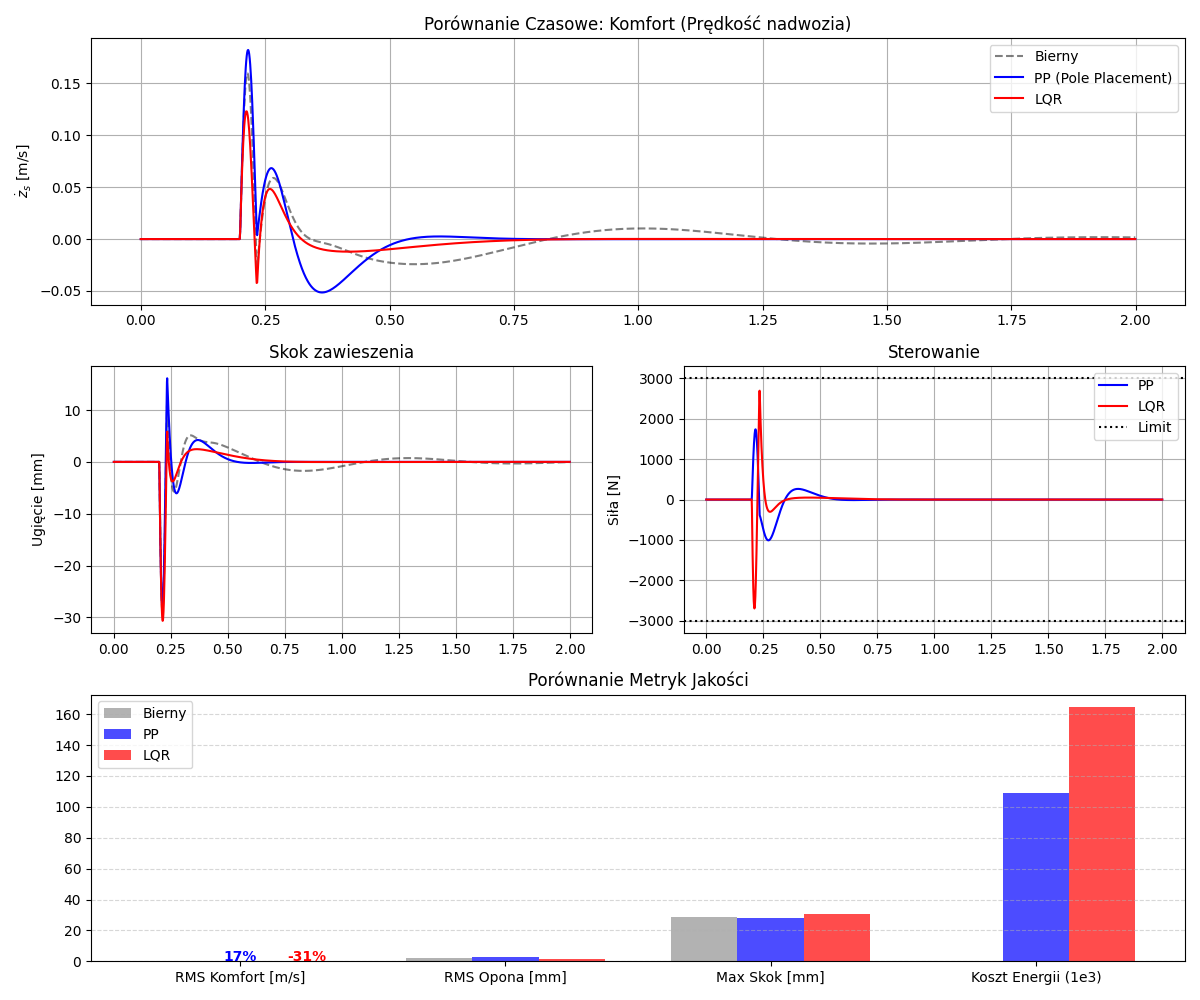


--- TABELA WYNIKÓW ---
Metryka                   | Bierny     | PP         | LQR       
-----------------------------------------------------------------
RMS Komfort [m/s]         | 0.0187     | 0.0219     | 0.0130
RMS Prowadzenie [mm]      | 1.89       | 2.49       | 1.33
Max Skok [mm]             | 28.8       | 28.0       | 30.6
Max Siła [N]              | 0          | 1737       | 2694


In [41]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from scipy import signal

# --- Upewnij się, że masz zdefiniowane K_pp i K_lqr z poprzednich kroków ---
# Jeśli nie, odkomentuj i wpisz wartości ręcznie (przykłady):
# K_pp = np.array([[88623.9, 13967.0, 61671.4, -552.1]]) 
# K_lqr = np.array([[20000.0, 3000.0, 5000.0, -100.0]]) # To tylko przykład!

def compare_controllers_visual(model, K_pp, K_lqr):
    """
    Porównuje wizualnie i numerycznie układ bierny, PP i LQR.
    Scenariusz: Pojedynczy garb (Sine Bump) - dla oceny redukcji RMS.
    """
    
    # 1. Generacja wymuszenia (Garb 4cm, długość 0.5m, prędkość 15 m/s)
    dt = 0.001
    speed = 15.0
    length = 0.5
    height = 0.04
    
    duration = 2.0
    t = np.arange(0, duration, dt)
    
    # Profil r(t) i r_dot(t)
    r = np.zeros_like(t)
    r_dot = np.zeros_like(t)
    
    # Czas trwania garbu
    bump_dur = length / speed
    start_t = 0.2
    end_t = start_t + bump_dur
    
    idx = (t >= start_t) & (t <= end_t)
    t_bump = t[idx] - start_t
    omega = np.pi * speed / length
    
    r[idx] = height * np.sin(omega * t_bump)
    r_dot[idx] = height * omega * np.cos(omega * t_bump)
    
    # 2. Przygotowanie modeli
    # Wejście: r_dot (kolumna 1 macierzy E)
    E_in = model.E[:, [1]]
    
    # A. Układ Bierny (u=0)
    sys_passive = ct.ss(model.A, E_in, model.C, np.zeros((3,1)))
    
    # B. Regulator PP
    A_pp = model.A - model.B @ K_pp
    # Wyjścia: [zs_dot, zu-r, zs-zu, u]
    C_reg_pp = np.vstack([model.C, -K_pp])
    sys_pp = ct.ss(A_pp, E_in, C_reg_pp, np.zeros((4,1)))
    
    # C. Regulator LQR
    A_lqr = model.A - model.B @ K_lqr
    C_reg_lqr = np.vstack([model.C, -K_lqr])
    sys_lqr = ct.ss(A_lqr, E_in, C_reg_lqr, np.zeros((4,1)))
    
    # 3. Symulacje
    _, y_pass = ct.forced_response(sys_passive, T=t, U=r_dot)
    _, y_pp = ct.forced_response(sys_pp, T=t, U=r_dot)
    _, y_lqr = ct.forced_response(sys_lqr, T=t, U=r_dot)
    
    # Obsługa wymiarów
    if y_pass.ndim == 1: y_pass = y_pass.reshape(3, -1)
    if y_pp.ndim == 1: y_pp = y_pp.reshape(4, -1)
    if y_lqr.ndim == 1: y_lqr = y_lqr.reshape(4, -1)
    
    # 4. Obliczenie Metryk
    def calc_mets(y, u=None):
        zs_dot = y[0]
        zu_r = y[1]
        zs_zu = y[2]
        
        rms_comf = np.sqrt(np.mean(zs_dot**2))
        rms_hand = np.sqrt(np.mean(zu_r**2))
        max_skok = np.max(np.abs(zs_zu))
        
        # Koszt energii (u^2)
        u_cost = 0
        max_u = 0
        if u is not None:
            if hasattr(np, 'trapezoid'): # Kompatybilność NumPy 2.0
                u_cost = np.trapezoid(u**2, t)
            else:
                u_cost = np.trapz(u**2, t)
            max_u = np.max(np.abs(u))
            
        return [rms_comf, rms_hand, max_skok, u_cost, max_u]

    m_pass = calc_mets(y_pass)
    m_pp = calc_mets(y_pp[:3], y_pp[3])
    m_lqr = calc_mets(y_lqr[:3], y_lqr[3])
    
    # 5. Wizualizacja
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(3, 2)
    
    # --- Wykresy Czasowe ---
    ax1 = fig.add_subplot(gs[0, :]) # Komfort
    ax1.plot(t, y_pass[0], 'k--', alpha=0.5, label='Bierny')
    ax1.plot(t, y_pp[0], 'b', label='PP (Pole Placement)')
    ax1.plot(t, y_lqr[0], 'r', label='LQR')
    ax1.set_ylabel(r'$\dot{z}_s$ [m/s]')
    ax1.set_title('Porównanie Czasowe: Komfort (Prędkość nadwozia)')
    ax1.legend()
    ax1.grid(True)
    
    ax2 = fig.add_subplot(gs[1, 0]) # Skok
    ax2.plot(t, y_pass[2]*1000, 'k--', alpha=0.5)
    ax2.plot(t, y_pp[2]*1000, 'b')
    ax2.plot(t, y_lqr[2]*1000, 'r')
    ax2.set_ylabel('Ugięcie [mm]')
    ax2.set_title('Skok zawieszenia')
    ax2.grid(True)
    
    ax3 = fig.add_subplot(gs[1, 1]) # Sterowanie
    ax3.plot(t, y_pp[3], 'b', label='PP')
    ax3.plot(t, y_lqr[3], 'r', label='LQR')
    ax3.axhline(model.u_max, color='k', linestyle=':', label='Limit')
    ax3.axhline(-model.u_max, color='k', linestyle=':')
    ax3.set_ylabel('Siła [N]')
    ax3.set_title('Sterowanie')
    ax3.legend()
    ax3.grid(True)
    
    # --- Wykresy Słupkowe (Porównanie Metryk) ---
    ax_bar = fig.add_subplot(gs[2, :])
    
    metrics_labels = ['RMS Komfort [m/s]', 'RMS Opona [mm]', 'Max Skok [mm]', 'Koszt Energii (1e3)']
    
    # Skalowanie do mm i jednostek czytelnych
    data_pass = [m_pass[0], m_pass[1]*1000, m_pass[2]*1000, 0]
    data_pp   = [m_pp[0],   m_pp[1]*1000,   m_pp[2]*1000,   m_pp[3]/1000]
    data_lqr  = [m_lqr[0],  m_lqr[1]*1000,  m_lqr[2]*1000,  m_lqr[3]/1000]
    
    x = np.arange(len(metrics_labels))
    width = 0.25
    
    ax_bar.bar(x - width, data_pass, width, label='Bierny', color='gray', alpha=0.6)
    ax_bar.bar(x, data_pp, width, label='PP', color='blue', alpha=0.7)
    ax_bar.bar(x + width, data_lqr, width, label='LQR', color='red', alpha=0.7)
    
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(metrics_labels)
    ax_bar.set_title('Porównanie Metryk Jakości')
    ax_bar.legend()
    ax_bar.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Dodanie procentowej zmiany RMS Komfort nad słupkami
    change_pp = (m_pp[0] - m_pass[0]) / m_pass[0] * 100
    change_lqr = (m_lqr[0] - m_pass[0]) / m_pass[0] * 100
    
    def add_label(rects, val):
        for rect in rects:
            height = rect.get_height()
            ax_bar.text(rect.get_x() + rect.get_width()/2., 1.05*height,
                    f'{val:+.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Etykiety tylko dla pierwszej grupy (RMS Komfort)
    ax_bar.text(x[0], data_pp[0]*1.1, f"{change_pp:.0f}%", ha='center', color='blue', fontweight='bold')
    ax_bar.text(x[0]+width, data_lqr[0]*1.1, f"{change_lqr:.0f}%", ha='center', color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- TABELA WYNIKÓW ---")
    print(f"{'Metryka':<25} | {'Bierny':<10} | {'PP':<10} | {'LQR':<10}")
    print("-" * 65)
    print(f"{'RMS Komfort [m/s]':<25} | {m_pass[0]:.4f}     | {m_pp[0]:.4f}     | {m_lqr[0]:.4f}")
    print(f"{'RMS Prowadzenie [mm]':<25} | {m_pass[1]*1000:.2f}       | {m_pp[1]*1000:.2f}       | {m_lqr[1]*1000:.2f}")
    print(f"{'Max Skok [mm]':<25} | {m_pass[2]*1000:.1f}       | {m_pp[2]*1000:.1f}       | {m_lqr[2]*1000:.1f}")
    print(f"{'Max Siła [N]':<25} | {0:<10} | {m_pp[4]:.0f}       | {m_lqr[4]:.0f}")

# Uruchomienie porównania (zakładając, że zmienne K_pp i K_lqr istnieją w pamięci notebooka)
if 'K_pp' in globals() and 'K_lqr' in globals():
    compare_controllers_visual(model, K_pp, K_lqr)
else:
    print("Zdefiniuj macierze K_pp i K_lqr przed uruchomieniem porównania!")